## Clustering

tomas.arteaga@edu.evolveacademy.es

tomas.arteagaprieto@gmail.com

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
#from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import silhouette_score
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np
from sklearn.cluster import KMeans
import math
from sklearn.decomposition import PCA

#### 0. Importamos datos

In [2]:
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\03 Aprendizaje no supervisado'

In [4]:
file='data\\Mall_Customers.csv'
df = pd.read_csv(file, delimiter=',', low_memory=False)
df.shape
#os.getcwd()
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


##### El set de datos proviene de aquí: https://www.kaggle.com/code/niteshyadav3103/customer-segmentation-using-kmeans-hc-dbscan?select=Mall_Customers.csv



In [5]:
df_original = df

In [6]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


#### 1. Preparación de datos

In [7]:
df.columns.tolist()

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

El dataset X contiene las variables input de mi analisis cluster

In [8]:
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


Seleccionamos las colummnas que vamos a emplear en el cluster

Transformamos las variables categoricas en variables dummies

In [9]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols
    
vbles = tipo_variables(X)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['Gender']
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


Convertimos las variables categóricas en numéricas

In [10]:
from sklearn.preprocessing import OneHotEncoder
# Crear un objeto OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
#El parámetro sparse_output=False asegura que la salida sea un array denso 
#(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.
for i in cat_vbles:
    encoded_data = encoder.fit_transform(X[[i]])
    column_names = encoder.get_feature_names_out([i])
    encoded_X=pd.DataFrame(encoded_data, columns=column_names)
    X = pd.concat([X, encoded_X], axis=1)

X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,Male,19,15,39,0.0,1.0
1,Male,21,15,81,0.0,1.0
2,Female,20,16,6,1.0,0.0
3,Female,23,16,77,1.0,0.0
4,Female,31,17,40,1.0,0.0


In [13]:
X.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Female',
       'Gender_Male'],
      dtype='object')

In [14]:
# quito las variables categoreicas originales 
X = X.drop(columns=cat_vbles)
X.head()

KeyError: "['Gender'] not found in axis"

In [15]:
columnas_a_borrar = ['Gender_Male']
X = X.drop(columns=columnas_a_borrar)
X

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female
0,19,15,39,0.0
1,21,15,81,0.0
2,20,16,6,1.0
3,23,16,77,1.0
4,31,17,40,1.0
...,...,...,...,...
195,35,120,79,1.0
196,45,126,28,1.0
197,32,126,74,0.0
198,32,137,18,0.0


In [16]:
X.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Female'], dtype='object')

In [17]:
X.shape

(200, 4)

In [18]:
# chequeamos que los tipos de datos son validos para un análisis cluster. En este caso todoa los valores deben ser numericos
X.dtypes

Age                         int64
Annual Income (k$)          int64
Spending Score (1-100)      int64
Gender_Female             float64
dtype: object

Verificamos si tenemos valores a null. En este ejemplo no hay, si hubiera tendríamos que tratarlos

In [19]:
nancol = X.isna().any()

nancol2=nancol.loc[nancol == 1].index.tolist()
nancol2

[]

Estandarizamos las variables

In [20]:
from sklearn.preprocessing import Normalizer

scaler = Normalizer().fit(X)
X_norm = scaler.transform(X)
X_norm[:10]


#X_norm = preprocessing.normalize(X)

#from sklearn.preprocessing import StandardScaler
# Estandarizar los datos

#scaler = StandardScaler()
#X_norm = scaler.fit_transform(X)
#X_norm

array([[0.41392469, 0.32678265, 0.84963489, 0.        ],
       [0.24702464, 0.17644617, 0.95280931, 0.        ],
       [0.75973718, 0.60778974, 0.22792115, 0.03798686],
       [0.28067571, 0.19525267, 0.93965346, 0.01220329],
       [0.58058136, 0.31838332, 0.74913723, 0.01872843],
       [0.27183291, 0.2100527 , 0.93905914, 0.01235604],
       [0.87885343, 0.45198176, 0.15066059, 0.0251101 ],
       [0.23365009, 0.18285659, 0.95491775, 0.0101587 ],
       [0.95768043, 0.28431138, 0.04489127, 0.        ],
       [0.37365957, 0.23665106, 0.89678296, 0.01245532]])

#### 2. K-Means

Utilizamos el métido K-Means, este método espera un a priori de numero de clusters. Hacemos un primer ejercicio para determinar el numero optimo de clusters empleando el coeficiente de silhouette.

<Axes: >

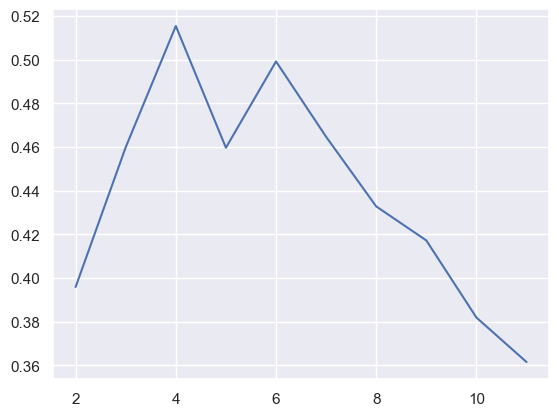

In [22]:
K = range(2, 12)
fits = []
score = []


for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0).fit(X_norm)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(X_norm, model.labels_, metric='euclidean'))


sns.lineplot(x = K, y = score)

In [23]:
# el k=4 es el que mejor funciona.
# ver como imputar el resultado

kmeans = KMeans(n_clusters=4)
kmeans.fit(X_norm)
y_kmeans = kmeans.predict(X_norm)

X['cluster']=y_kmeans
X.head()
X.groupby("cluster").size()
# Analisis descriptivo vs cluster. ver si se puede automatizar algo ... 

cluster
0    37
1    25
2    60
3    78
dtype: int64

In [24]:
#Ahora le pego el num de cluster

X_ori2 = pd.merge(df, X[['cluster']], left_index=True, right_index=True)
X_ori2

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,2
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,0
197,198,Male,32,126,74,3
198,199,Male,32,137,18,0


In [25]:
X_ori2.shape

(200, 6)

In [26]:
X_ori2.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,2
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1
5,6,Female,22,17,76,1
6,7,Female,35,18,6,2
7,8,Female,23,18,94,1
8,9,Male,64,19,3,2
9,10,Female,30,19,72,1


In [27]:
# selecciono las variables continuas para describirlas como son sus medias y medianas. 

print(cat_vbles)
print(num_vbles)

['Gender']
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [28]:
# Construyo la tabla de medias:

table_avg = pd.pivot_table(X_ori2, values=num_vbles, index=['cluster'],
                       aggfunc='mean')
table_avg

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,40.729730,87.297297,18.054054
1,25.480000,25.480000,75.440000
2,53.516667,44.166667,38.583333
3,30.961538,71.730769,66.294872


In [29]:
table_median = pd.pivot_table(X_ori2, values=num_vbles, index=['cluster'],
                       aggfunc='median')
table_median

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,42.0,81.0,16.0
1,24.0,24.0,76.0
2,52.5,46.5,44.5
3,31.0,69.5,61.5


##### 2.1 Visualizamos los resultados del k_means

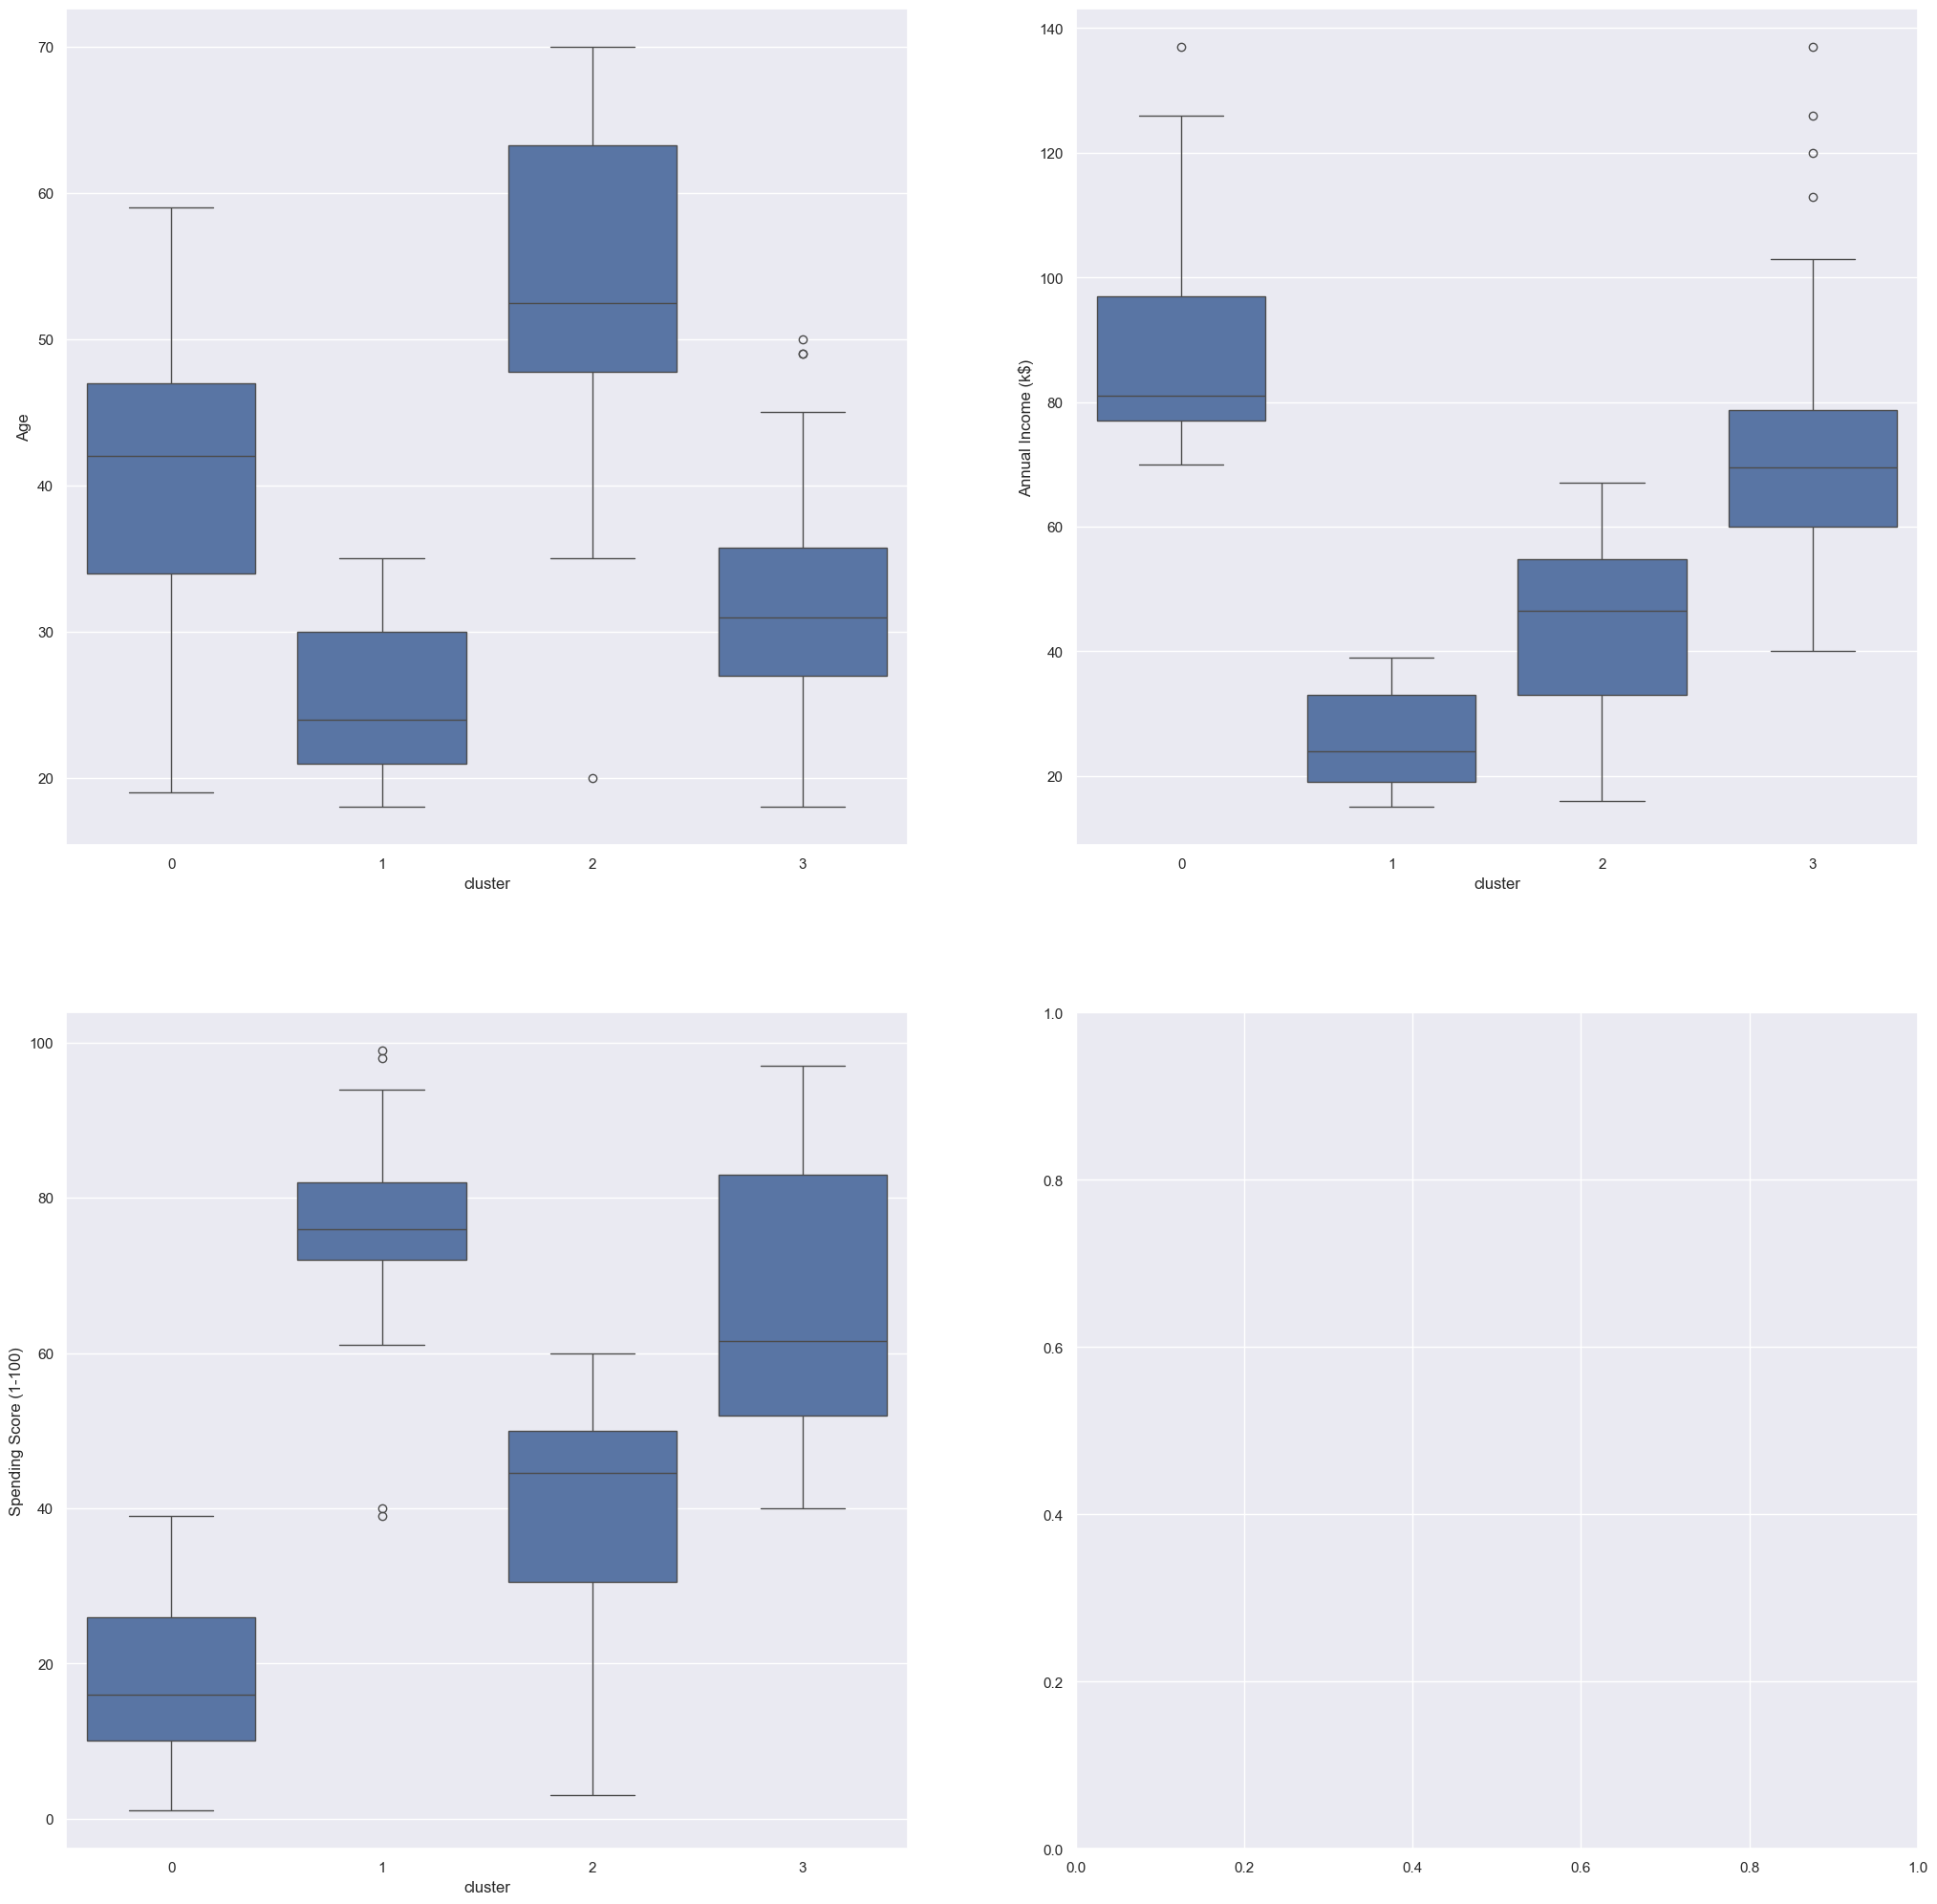

In [30]:

a= math.floor(math.sqrt(len(num_vbles)))+1

fig, axes = plt.subplots(a, a, figsize=(25,25))
axes = axes.flatten()
i = 0
for t in num_vbles:
    ax = sns.boxplot(x='cluster', y=t, data=X_ori2, orient='v', 
    ax=axes[i])
    i +=1

In [31]:
X_ori2

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,2
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,0
197,198,Male,32,126,74,3
198,199,Male,32,137,18,0


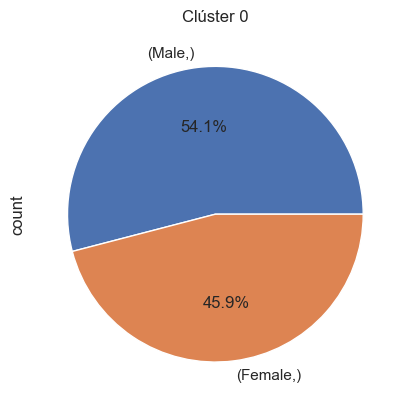

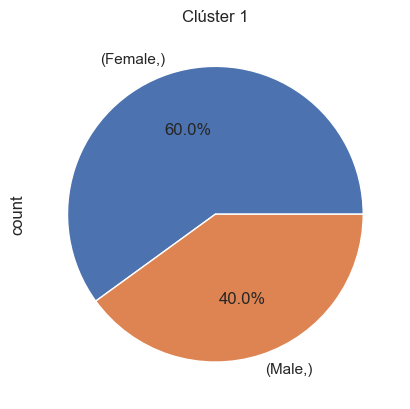

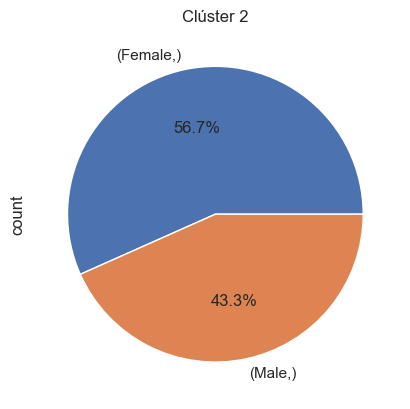

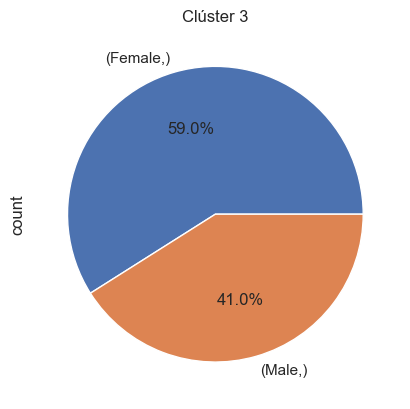

In [32]:
n_clus = X_ori2['cluster'].sort_values().unique()
palette_color = sns.color_palette('bright') 

chars1 = cat_vbles
#fig, ax = plt.subplots(len(chars1), len(n_clus), figsize=(20,20))


if len(chars1) == 1:
     for j in range(len(n_clus)): 
        filtered_data = X_ori2.loc[ X_ori2['cluster'] == j]
        plt.figure() 
        filtered_data[chars1].value_counts().plot(kind='pie' , autopct='%1.1f%%')
        plt.title(f'Clúster {j}')
        plt.show()
else:
    
    k = 0
    i = 0
    j = 0
    fig, ax = plt.subplots(1, 4, figsize=(25,25))
    for i in range(len(chars1)-1):
        for j in range(len(n_clus)-1):
            table = pd.pivot_table(X_ori2.loc[X_ori2['cluster']==n_clus[j]], values='cluster', index=[chars1[i]], aggfunc='count')
            vals = table['cluster'].values
            my_labels = table.index
            title = "Var: "+my_labels.name+"; Cluster: "+str(n_clus[j])
            ax[i,j].pie(vals,
                       labels =  my_labels, 
                        autopct=lambda p: '{:.0f}%'.format(p),
                        startangle=90, shadow = False)
            ax[i,j].set_title(title)
            k+=1
            
            
    
    plt.tight_layout()
    fig.savefig('subplots.png')
    plt.show()

##### 2.2 Analisis PCA para representar los clusters en dos ejes 

In [33]:
pca = PCA(2)
data = pca.fit_transform(X_norm)
print(data[:10])

[[ 0.41449587  0.1460967 ]
 [ 0.61798222  0.10019825]
 [-0.33628119  0.28793214]
 [ 0.58867462  0.11606863]
 [ 0.28620132  0.28922933]
 [ 0.5839081   0.10006754]
 [-0.36380097  0.48246732]
 [ 0.62064059  0.0856612 ]
 [-0.39835359  0.65448639]
 [ 0.50704078  0.16666298]]


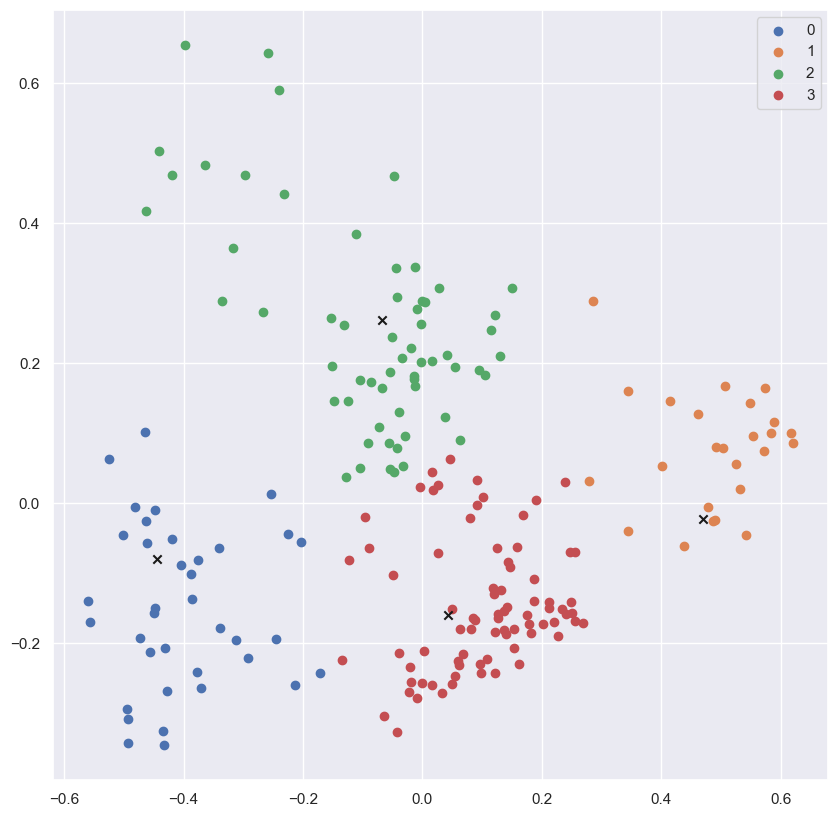

In [35]:
centers = pca.fit_transform(np.array(kmeans.cluster_centers_))
label = y_kmeans
#label = kmeans.fit_predict(data)
# 
plt.figure(figsize=(10,10))
uniq = np.unique(label)
for i in uniq:
   plt.scatter(data[label == i , 0] , data[label == i , 1] , label = i)
plt.scatter(centers[:,0], centers[:,1], marker="x", color='k')

#This is done to find the centroid for each clusters.
plt.legend()
plt.show()

#### 3. Hierarchical Clustering

In [36]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [37]:
X_norm[:10]

array([[0.41392469, 0.32678265, 0.84963489, 0.        ],
       [0.24702464, 0.17644617, 0.95280931, 0.        ],
       [0.75973718, 0.60778974, 0.22792115, 0.03798686],
       [0.28067571, 0.19525267, 0.93965346, 0.01220329],
       [0.58058136, 0.31838332, 0.74913723, 0.01872843],
       [0.27183291, 0.2100527 , 0.93905914, 0.01235604],
       [0.87885343, 0.45198176, 0.15066059, 0.0251101 ],
       [0.23365009, 0.18285659, 0.95491775, 0.0101587 ],
       [0.95768043, 0.28431138, 0.04489127, 0.        ],
       [0.37365957, 0.23665106, 0.89678296, 0.01245532]])

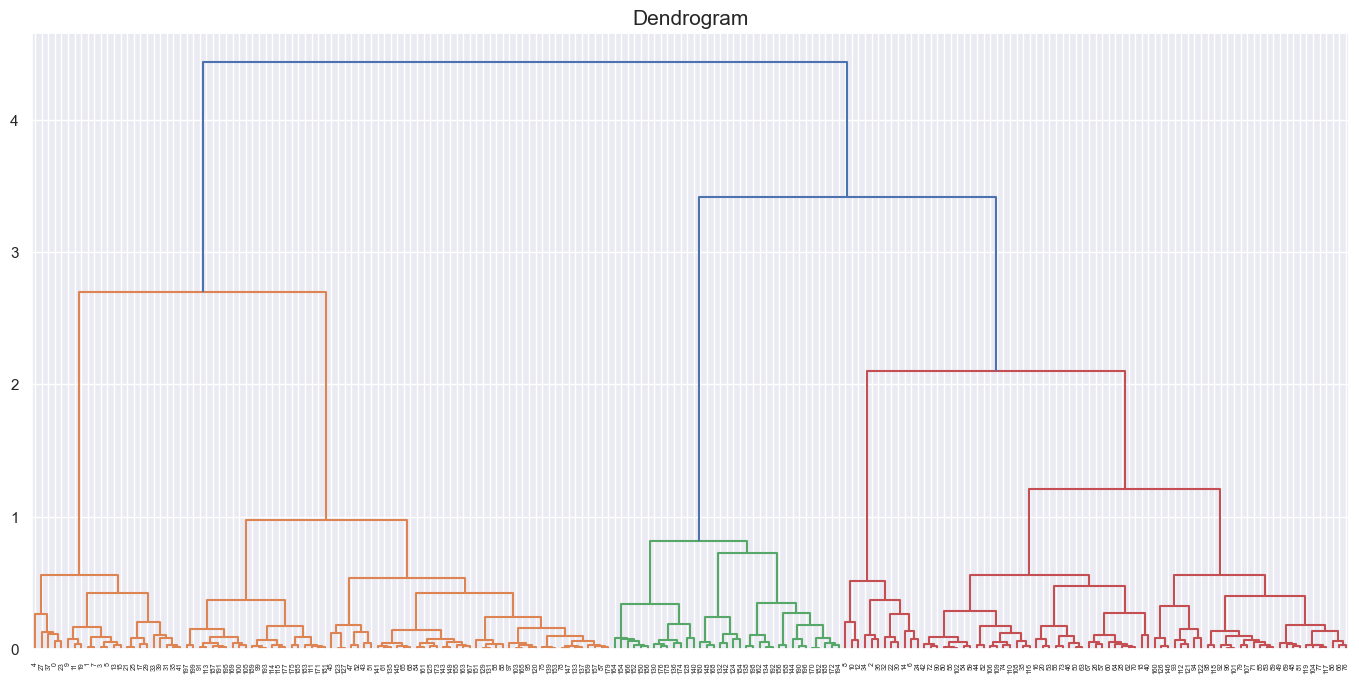

In [38]:
plt.figure(figsize = (17, 8))

dendo = dendrogram(linkage(X_norm, method = 'ward'))
plt.title('Dendrogram', fontsize = 15)
plt.show()

In [39]:
# Aplicar el clustering jerárquico con scikit-learn
agc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage = 'ward')
hc_labels = agc.fit_predict(X_norm)
hc_labels

array([3, 3, 4, 3, 3, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0, 3, 0, 3, 0, 3,
       4, 3, 4, 3, 0, 3, 0, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0, 3, 0, 3, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

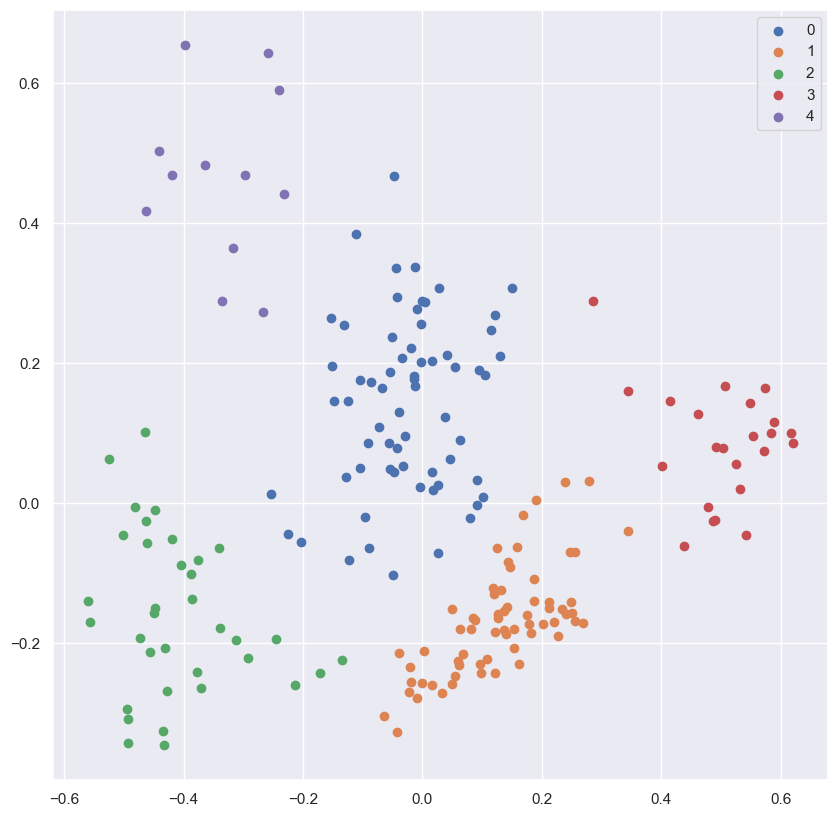

In [40]:
# en el cluster jerarquico no se utilizan centroides 
#centers = np.array(agc.cluster_centers_)
label = hc_labels
#label = kmeans.fit_predict(data)

plt.figure(figsize=(10,10))
uniq = np.unique(label)
for i in uniq:
   plt.scatter(data[label == i , 0] , data[label == i , 1] , label = i)
#plt.scatter(centers[:,0], centers[:,1], marker="x", color='k')
# los centroides están raros 
#This is done to find the centroid for each clusters.
plt.legend()
plt.show()

#### 4. DBSCAN

El parámetro "eps" es un número positivo que especifica el radio del vecindario alrededor de cada punto. Esto significa que cualquier par de puntos cuya distancia sea menor o igual a eps se consideran parte del mismo grupo (cluster).  

El parámetro "min_samples" es el número mínimo de puntos requerido para formar una región densa. Los puntos que no forman parte de una región densa se consideran ruido.


In [41]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [42]:
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan.fit(X_norm)
dbs_labels = dbscan.labels_ 
np.unique(dbs_labels)

array([-1,  0,  1,  2])

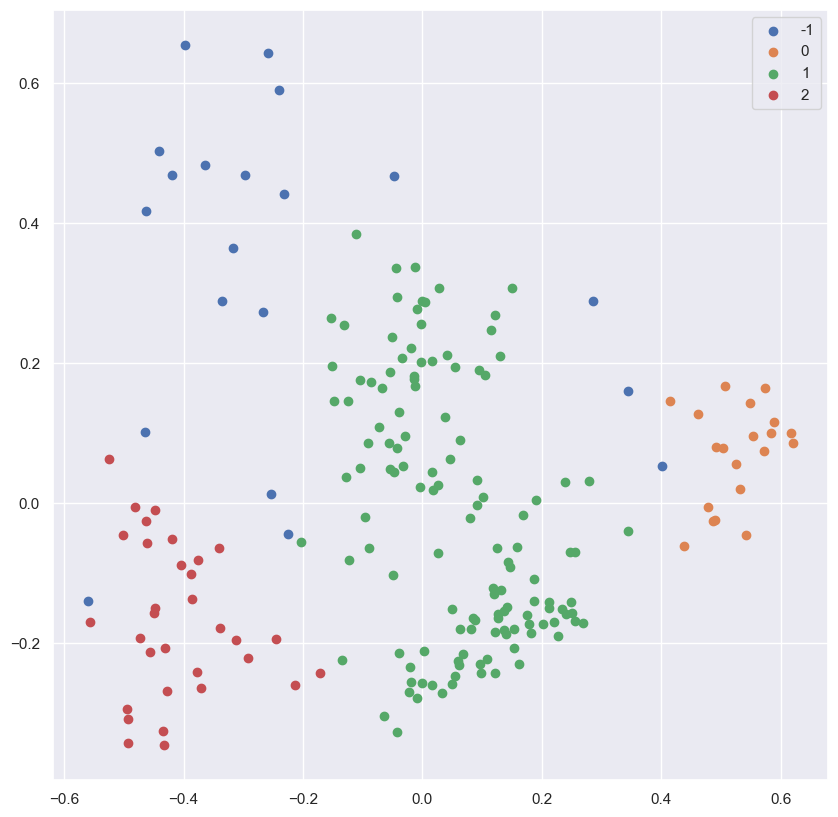

In [43]:
# en el cluster jerarquico no se utilizan centroides 
#centers = np.array(agc.cluster_centers_)
label = dbs_labels
#label = kmeans.fit_predict(data)

plt.figure(figsize=(10,10))
uniq = np.unique(label)
for i in uniq:
   plt.scatter(data[label == i , 0] , data[label == i , 1] , label = i)
#plt.scatter(centers[:,0], centers[:,1], marker="x", color='k')
# los centroides están raros 
#This is done to find the centroid for each clusters.
plt.legend()
plt.show()